# PHASE 4: STATISTICAL ANALYSIS & RELATIONSHIP TESTING


## 1. Business Objective
**Which measurable station and infrastructure characteristics are associated with charging demand, utilization, energy delivery, and congestion?**

The goal is to determine which structural and categorical relationships are statistically robust enough to justify feature engineering and Machine Learning in subsequent phases, without falsely equating association with causation.


## 2. Statistical Questions
### Demand / Infrastructure
- Is station demand associated with number of chargers?
- Is station demand associated with maximum station power?
- Is energy delivered associated with station capacity?
- Does parking capacity relate to station demand?

### Charger / Station Type
- Do different charger types have different energy/session characteristics?
- Do different station types have different utilization?
- Are congestion rates different between station categories?

### Utilization
- Which infrastructure variables are associated with utilization?
- Are highly utilized stations systematically different from low-utilization stations?

### Congestion
- Which measurable variables are associated with congestion?
- Does charger capacity reduce or increase observed congestion?
- Are high-demand stations disproportionately congestion-prone?


## 3. Load Data
Importing necessary libraries including `scipy.stats` and `statsmodels` for rigorous statistical testing. We read directly from the immutable `data/raw/` directory.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RAW_DIR = r"C:\PYTHON p45\EV-Charging-Infrastructure-Analytics-Demand-Forecasting-Utilization-Optimization\Project_files\data\raw"

sessions = pd.read_csv(f"{RAW_DIR}/charging_sessions.csv")
stations = pd.read_csv(f"{RAW_DIR}/stations.csv")
metrics = pd.read_csv(f"{RAW_DIR}/station_hourly_metrics.csv")


## 4. Prepare Analysis Dataset
We aggregate the session and metric logs up to the Station Level to perform cross-sectional analysis, matching our findings from Phase 3A (that temporal variance is flat).


In [11]:
# Aggregate Metrics per Station
station_agg = metrics.groupby('Station_ID').agg(
    Total_Sessions=('Sessions_Count', 'sum'),
    Total_Energy_kWh=('Energy_Delivered_kWh', 'sum'),
    Avg_Utilization=('Utilization_Rate', 'mean'),
    Avg_Wait_Time=('Avg_Wait_Time_Min', 'mean'),
    Congestion_Freq=('Congestion_Flag', 'mean') # mean of boolean flag is frequency
).reset_index()

# Merge with Station Infrastructure metadata
df = pd.merge(station_agg, stations, on='Station_ID', how='inner')

# Clean any missing or Infinite variants just in case (data is pristine, but standard practice)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print(f"Analysis dataset prepared with {len(df)} stations and {len(df.columns)} features.")


Analysis dataset prepared with 5000 stations and 25 features.


## 5. Descriptive Statistics
Calculating rigorous distribution metrics (count, mean, median, standard deviation, min, max, quartiles, IQR) to understand the data's shape before applying parametric assumptions.


,count,mean,50%,std,min,max,25%,75%,IQR
Total_Sessions,5000.0,100.000000,99.000000,50.215132,7.000000,224.000000,58.000000,143.000000,85.000000
Total_Energy_kWh,5000.0,1709.219400,1688.717500,862.821503,116.222000,3836.539000,985.692750,2432.657250,1446.964500
Avg_Utilization,5000.0,0.389592,0.285625,0.254244,0.096816,0.952287,0.199405,0.511650,0.312245
Avg_Wait_Time,5000.0,3.396148,2.623837,2.429763,0.256667,10.876957,1.527765,4.744071,3.216306
Congestion_Freq,5000.0,0.247297,0.129032,0.265073,0.000000,0.914530,0.071429,0.287092,0.215664
Number_of_Chargers,5000.0,3.606600,3.000000,1.971145,1.000000,8.000000,2.000000,5.000000,3.000000
Max_Station_Power_kW,5000.0,517.747600,300.000000,597.532792,22.000000,2800.000000,110.000000,700.000000,590.000000
Parking_Spots,5000.0,5.519600,5.000000,2.874103,1.000000,10.000000,3.000000,8.000000,5.000000
Station_Age_Years,5000.0,9.430600,9.000000,4.004746,3.000000,16.000000,6.000000,13.000000,7.000000


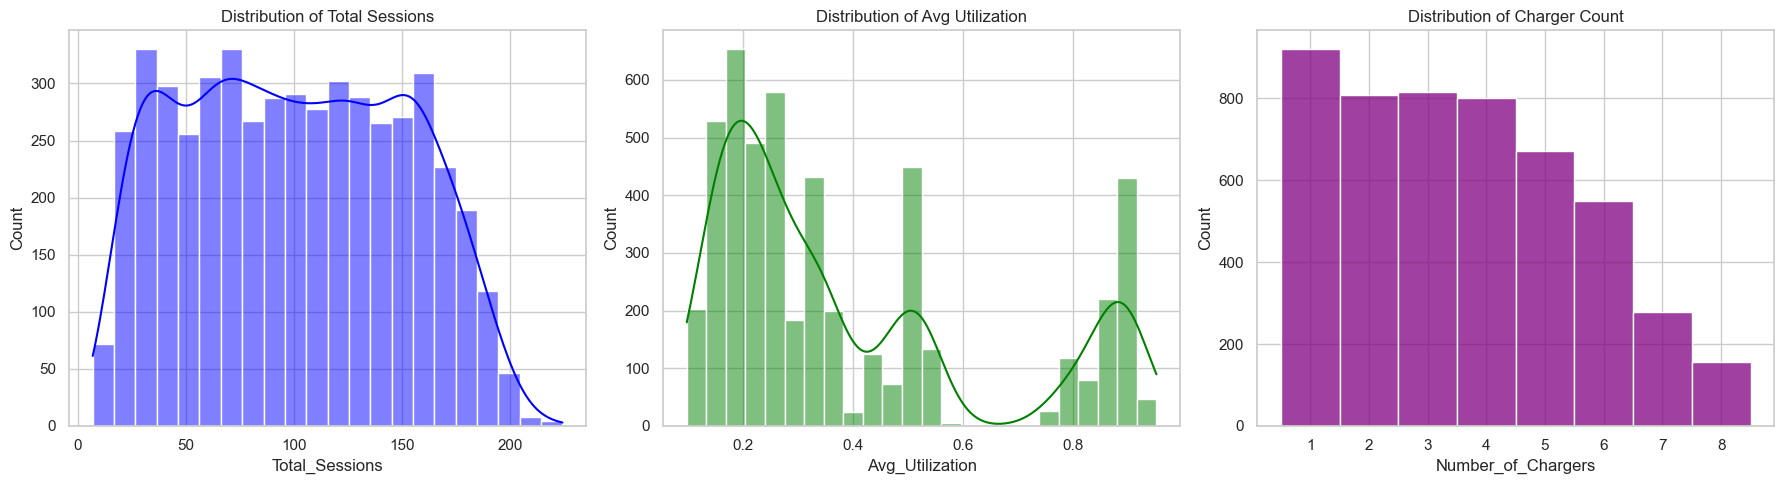

In [12]:
numeric_cols = [
    'Total_Sessions', 'Total_Energy_kWh', 'Avg_Utilization', 
    'Avg_Wait_Time', 'Congestion_Freq', 'Number_of_Chargers', 
    'Max_Station_Power_kW', 'Parking_Spots', 'Station_Age_Years'
]

desc = df[numeric_cols].describe().T
desc['IQR'] = desc['75%'] - desc['25%']

display(desc[['count', 'mean', '50%', 'std', 'min', 'max', '25%', '75%', 'IQR']])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['Total_Sessions'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Total Sessions')

sns.histplot(df['Avg_Utilization'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Avg Utilization')

sns.histplot(df['Number_of_Chargers'], discrete=True, ax=axes[2], color='purple')
axes[2].set_title('Distribution of Charger Count')

plt.tight_layout()
plt.show()


## 6. Correlation Analysis
We apply both **Pearson** (linear relationship) and **Spearman** (monotonic, rank-based relationship) correlation matrices. Because some underlying synthetic variables may not strictly follow normal distributions, Spearman acts as a robust check.


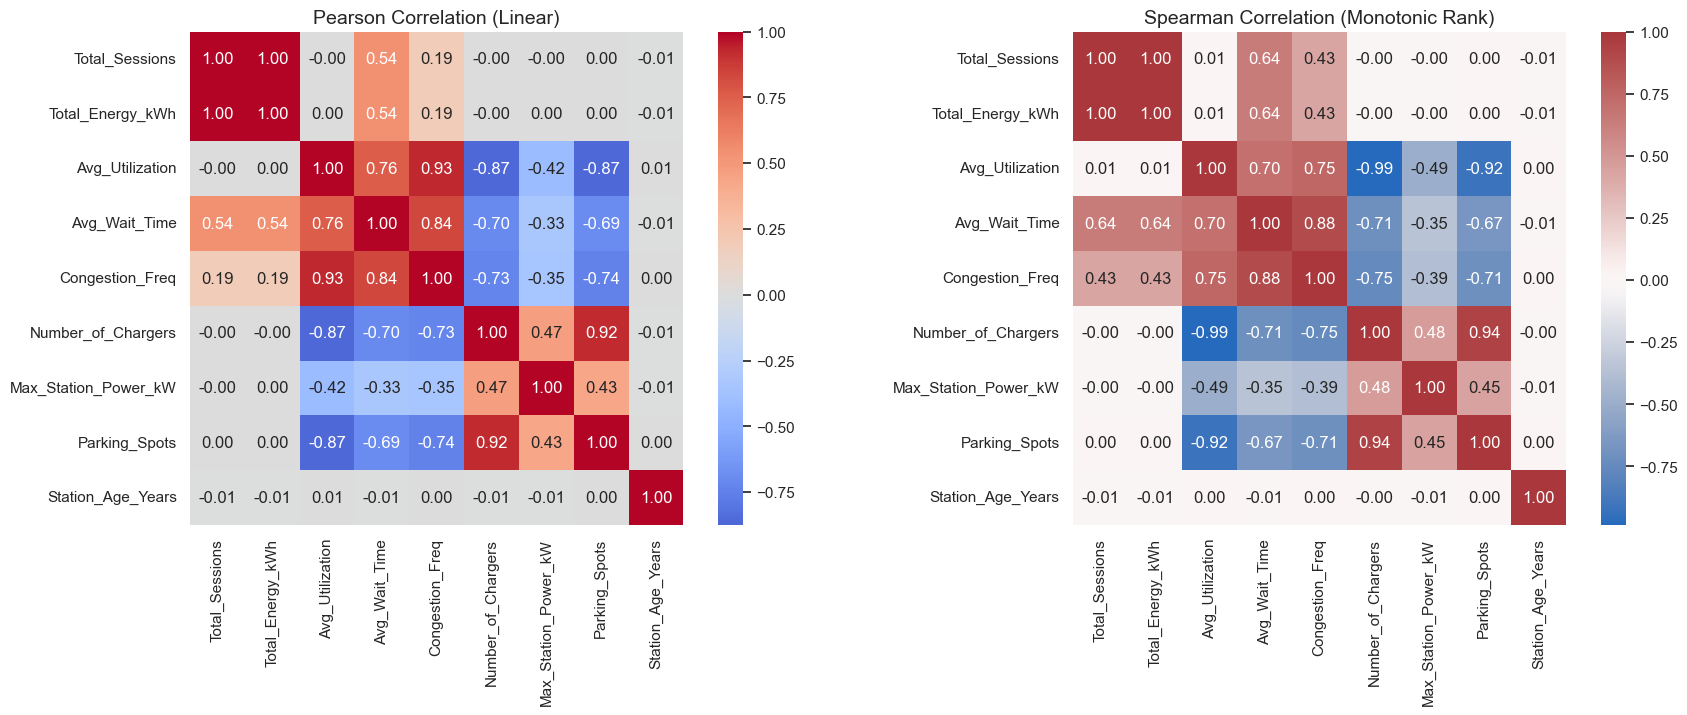

--- KEY BIVARIATE RELATIONSHIPS ---
Number_of_Chargers vs Total_Sessions:
  Pearson:  r = -0.001 (p = 9.540e-01)
  Spearman: rho = -0.002 (p = 8.884e-01)

Max_Station_Power_kW vs Total_Energy_kWh:
  Pearson:  r = 0.000 (p = 9.781e-01)
  Spearman: rho = -0.003 (p = 8.377e-01)

Parking_Spots vs Avg_Utilization:
  Pearson:  r = -0.875 (p = 0.000e+00)
  Spearman: rho = -0.923 (p = 0.000e+00)

Congestion_Freq vs Avg_Utilization:
  Pearson:  r = 0.931 (p = 0.000e+00)
  Spearman: rho = 0.747 (p = 0.000e+00)



In [13]:
# Pearson Matrix
pearson_corr = df[numeric_cols].corr(method='pearson')

# Spearman Matrix 
spearman_corr = df[numeric_cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0], square=True)
axes[0].set_title('Pearson Correlation (Linear)', fontsize=14)

sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[1], square=True)
axes[1].set_title('Spearman Correlation (Monotonic Rank)', fontsize=14)
plt.tight_layout()
plt.show()

# Extracting Important Relationships
def report_corr(var1, var2):
    p_stat, p_pval = stats.pearsonr(df[var1], df[var2])
    s_stat, s_pval = stats.spearmanr(df[var1], df[var2])
    print(f"{var1} vs {var2}:")
    print(f"  Pearson:  r = {p_stat:.3f} (p = {p_pval:.3e})")
    print(f"  Spearman: rho = {s_stat:.3f} (p = {s_pval:.3e})\n")

print("--- KEY BIVARIATE RELATIONSHIPS ---")
report_corr('Number_of_Chargers', 'Total_Sessions')
report_corr('Max_Station_Power_kW', 'Total_Energy_kWh')
report_corr('Parking_Spots', 'Avg_Utilization')
report_corr('Congestion_Freq', 'Avg_Utilization')


## 7. Group Comparison Tests
We use inferential tests (**T-Test** / **Mann-Whitney U** for two groups, **ANOVA** / **Kruskal-Wallis** for 3+ groups) to determine if outcome metrics systematically differ based on categorical configurations (like Charger Type or Station Type).

*   **Null Hypothesis ($H_0$)**: There is strictly no difference in outcome means/ranks between groups.
*   **Alternative Hypothesis ($H_A$)**: At least one group differs significantly from the others.



--- Test: Charger_Type -> Avg_Utilization ---
Null Hypothesis (H0): Real median Avg_Utilization is equal across all Charger_Type groups.
Alternative (HA): Avg_Utilization differs between Charger_Type groups.
Kruskal-Wallis Result: Test Statistic = 56.616, p-value = 5.081e-13
Conclusion: REJECT H0. There are statistically significant differences.

--- Test: Station_Type -> Total_Sessions ---
Null Hypothesis (H0): Real median Total_Sessions is equal across all Station_Type groups.
Alternative (HA): Total_Sessions differs between Station_Type groups.
Kruskal-Wallis Result: Test Statistic = 1.151, p-value = 5.625e-01
Conclusion: FAIL TO REJECT H0. No statistically significant differences detected.

--- Test: Renewable_Energy_Source -> Congestion_Freq ---
Null Hypothesis (H0): Real median Congestion_Freq is equal across all Renewable_Energy_Source groups.
Alternative (HA): Congestion_Freq differs between Renewable_Energy_Source groups.
Kruskal-Wallis Result: Test Statistic = 4.429, p-value

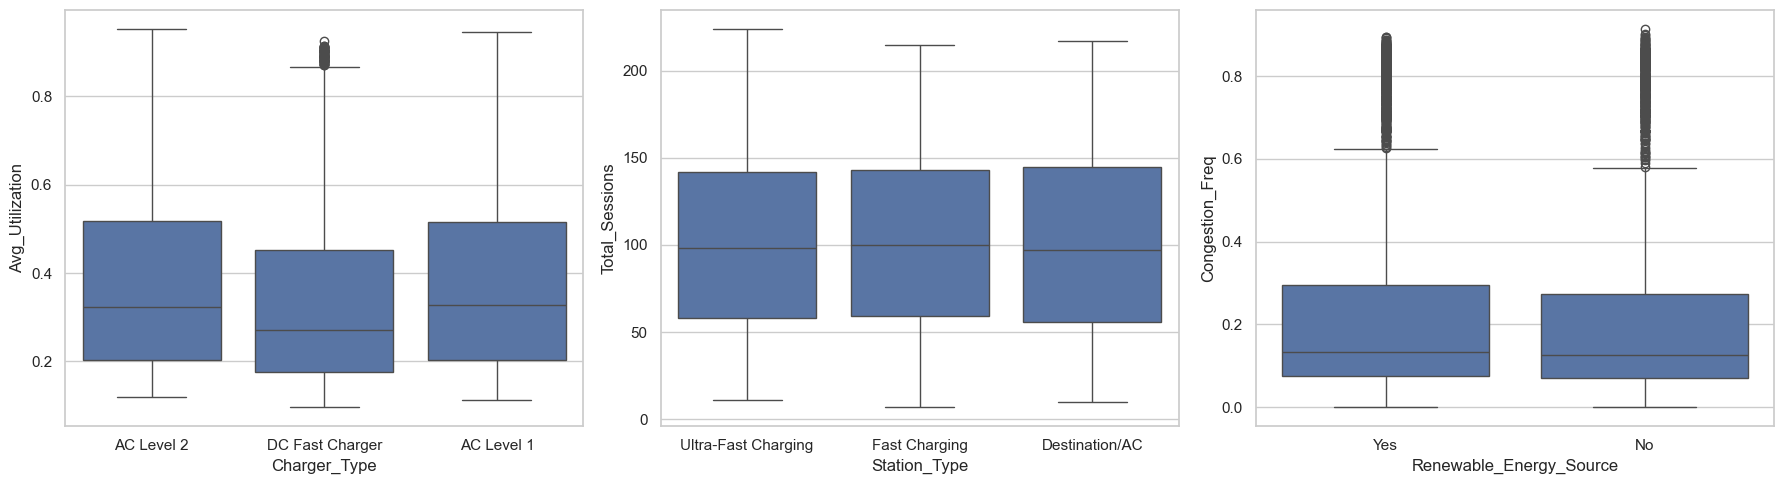

In [14]:
def test_groups(cat_var, num_var):
    groups = [group[num_var].values for name, group in df.groupby(cat_var)]
    
    print(f"\n--- Test: {cat_var} -> {num_var} ---")
    
    # Kruskal-Wallis (Non-Parametric alternative to ANOVA, robust to varying variances & distributions)
    stat, p = stats.kruskal(*groups)
    
    print(f"Null Hypothesis (H0): Real median {num_var} is equal across all {cat_var} groups.")
    print(f"Alternative (HA): {num_var} differs between {cat_var} groups.")
    print(f"Kruskal-Wallis Result: Test Statistic = {stat:.3f}, p-value = {p:.3e}")
    if p < 0.05:
        print(f"Conclusion: REJECT H0. There are statistically significant differences.")
    else:
        print(f"Conclusion: FAIL TO REJECT H0. No statistically significant differences detected.")

test_groups('Charger_Type', 'Avg_Utilization')
test_groups('Station_Type', 'Total_Sessions')
test_groups('Renewable_Energy_Source', 'Congestion_Freq')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=df, x='Charger_Type', y='Avg_Utilization', ax=axes[0])
sns.boxplot(data=df, x='Station_Type', y='Total_Sessions', ax=axes[1])
sns.boxplot(data=df, x='Renewable_Energy_Source', y='Congestion_Freq', ax=axes[2])
plt.tight_layout()
plt.show()


## 8. Station Infrastructure Relationships
Focused validation of operational metrics against physical capacities. We compare dimensions conceptually identified during Phase 3A.


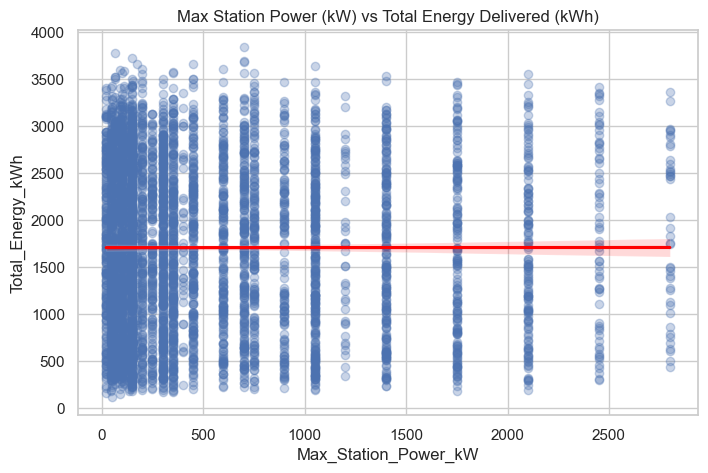

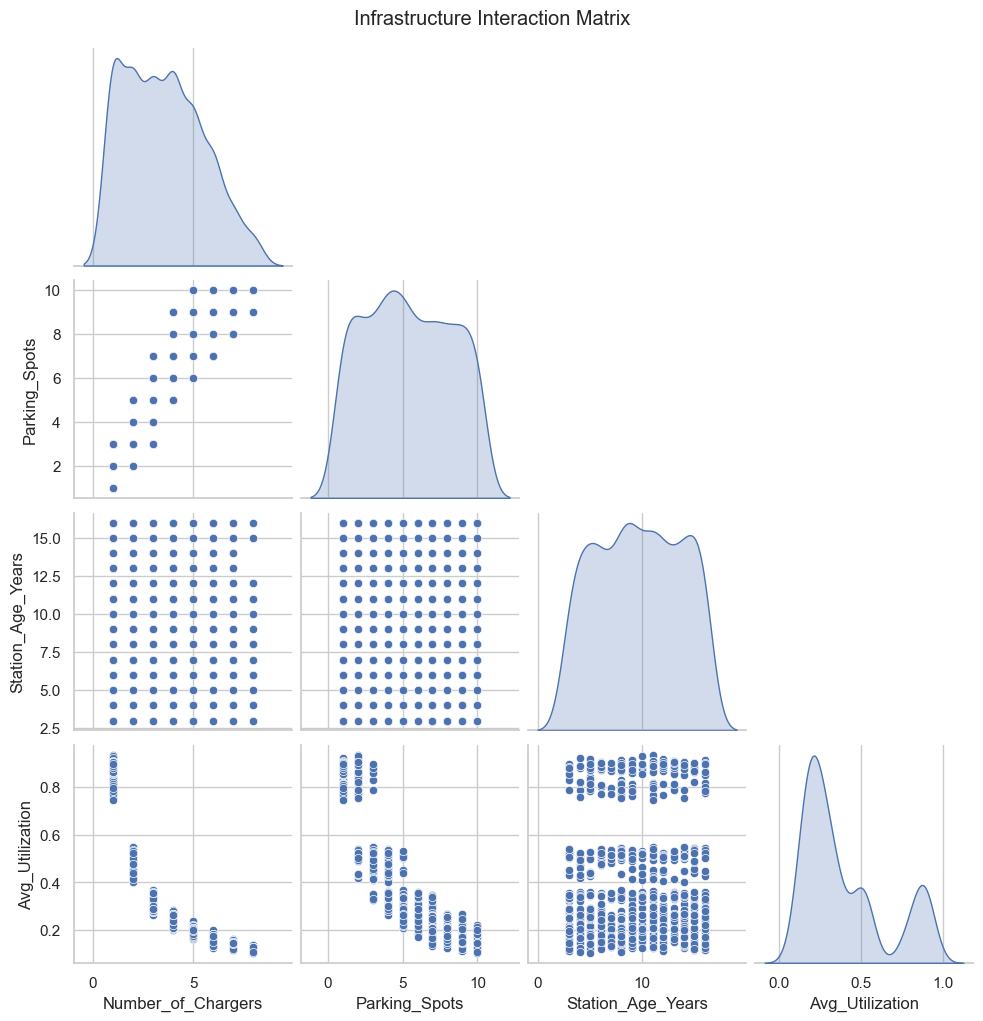

In [15]:
# Capacity vs Delivered
fig, ax = plt.subplots(figsize=(8,5))
sns.regplot(data=df, x='Max_Station_Power_kW', y='Total_Energy_kWh', scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, ax=ax)
ax.set_title("Max Station Power (kW) vs Total Energy Delivered (kWh)")
plt.show()

# Pairplot for Infrastructure variables and Demand
sample = df[['Number_of_Chargers', 'Parking_Spots', 'Station_Age_Years', 'Avg_Utilization']].sample(min(1000, len(df)))
sns.pairplot(sample, diag_kind='kde', corner=True)
plt.suptitle("Infrastructure Interaction Matrix", y=1.02)
plt.show()


## 9. Utilization & Congestion Analysis
We establish analytical definitions based on percentiles to segment the network:
*   **High Utilization (Q4)**: Above the 75th percentile of Avg_Utilization.
*   **Low Utilization (Q1)**: Below the 25th percentile of Avg_Utilization.
*   **High Congestion (Q4)**: Above the 75th percentile of Congestion_Freq.

We test if physical attributes heavily skew towards one of these categories.


In [16]:
util_75 = df['Avg_Utilization'].quantile(0.75)
util_25 = df['Avg_Utilization'].quantile(0.25)
cong_75 = df['Congestion_Freq'].quantile(0.75)

df['Util_Class'] = np.where(df['Avg_Utilization'] >= util_75, 'High', 
                           np.where(df['Avg_Utilization'] <= util_25, 'Low', 'Normal'))
df['Cong_Class'] = np.where(df['Congestion_Freq'] >= cong_75, 'High', 'Normal/Low')

print(f"High Utilization Threshold: {util_75:.3f}")
print(f"Low Utilization Threshold: {util_25:.3f}")
print(f"High Congestion Threshold: {cong_75:.3f}")

# Compare Number of Chargers in High vs Low Utilization
high_util_chargers = df[df['Util_Class']=='High']['Number_of_Chargers']
low_util_chargers = df[df['Util_Class']=='Low']['Number_of_Chargers']

stat_mw, p_mw = stats.mannwhitneyu(high_util_chargers, low_util_chargers)
print(f"\nMann-Whitney U Test (High vs Low Util for Charger Count): stat={stat_mw:.2f}, p-val={p_mw:.3e}")

summary_df = df.groupby('Util_Class')['Number_of_Chargers'].mean()
print("\nMean Number of Chargers by Utilization Class:")
print(summary_df)


High Utilization Threshold: 0.512
Low Utilization Threshold: 0.199
High Congestion Threshold: 0.287

Mann-Whitney U Test (High vs Low Util for Charger Count): stat=0.00, p-val=0.000e+00

Mean Number of Chargers by Utilization Class:
Util_Class
High      1.2640
Low       6.2544
Normal    3.4540
Name: Number_of_Chargers, dtype: float64


## 10. Regression Analysis
Building an interpretable cross-sectional baseline OLS (Ordinary Least Squares) regression. This tests the marginal impact of multiple predictors simultaneously.

**Equation:** `Total_Sessions ~ Number_of_Chargers + Max_Station_Power_kW + Parking_Spots + Station_Age_Years + C(Charger_Type)`


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Total_Sessions   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.4771
Date:                Wed, 23 Sep 2026   Prob (F-statistic):              0.873
Time:                        01:38:46   Log-Likelihood:                -26674.
No. Observations:                5000   AIC:                         5.337e+04
Df Residuals:                    4991   BIC:                         5.342e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==========================================================================================================
                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                100.7351      2.102     47.913      0.000      96.613     104.857
C(Station_Type)[T.Fast Charging]           0.6681      1.904      0.351      0.726      -3.064       4.400
C(Station_Type)[T.Ultra-Fast Charging]    -2.7924      3.617     -0.772      0.440      -9.883       4.298
C(Charger_Type)[T.AC Level 2]              0.4995      1.725      0.290      0.772      -2.882       3.881
C(Charger_Type)[T.DC Fast Charger]        -1.7181      1.768     -0.972      0.331      -5.184       1.748
Num_Chg_Z                                 -1.3958      1.978     -0.706      0.480      -5.273       2.481
Max_Pwr_Z                                  1.2011      1.502      0.800      0.424      -1.743       4.146
Park_Z                                     0.8640      1.837      0.470      0.638      -2.738       4.466
Age_Z                                     -0.3178      0.711     -0.447      0.655      -1.711       1.076
==============================================================================
Omnibus:                     2005.855   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              256.424
Skew:                           0.078   Prob(JB):                     2.08e-56
Kurtosis:                       1.902   Cond. No.                         9.37
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

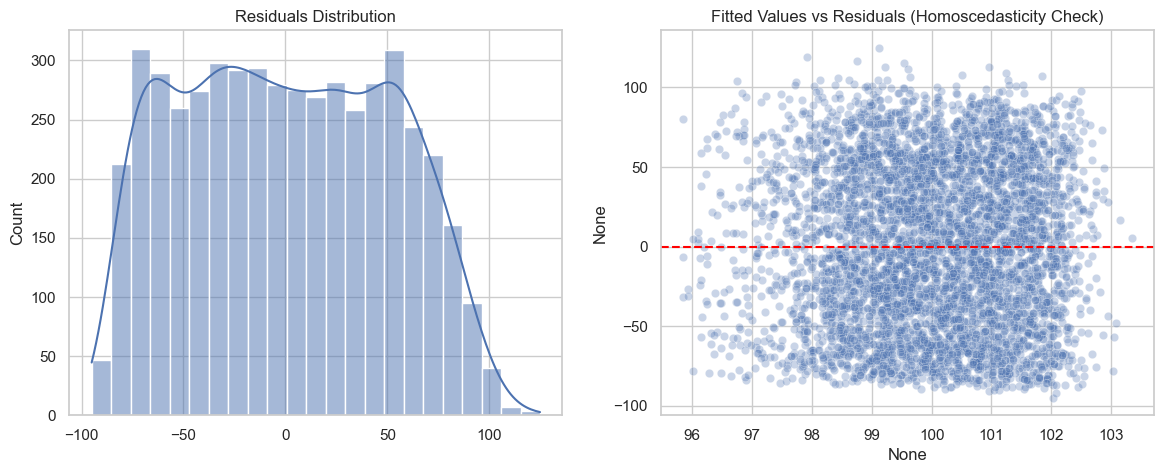

In [17]:
# We standardize numerical values to make coefficients comparable
df['Num_Chg_Z'] = stats.zscore(df['Number_of_Chargers'])
df['Max_Pwr_Z'] = stats.zscore(df['Max_Station_Power_kW'])
df['Park_Z']    = stats.zscore(df['Parking_Spots'])
df['Age_Z']     = stats.zscore(df['Station_Age_Years'])

# Dependent variable: Total Sessions
# Independent terms handling categorical encoding via patsy strings
formula = "Total_Sessions ~ Num_Chg_Z + Max_Pwr_Z + Park_Z + Age_Z + C(Station_Type) + C(Charger_Type)"

model = smf.ols(formula=formula, data=df).fit()
display(model.summary())

# Residual check
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Residuals Distribution')

sns.scatterplot(x=model.fittedvalues, y=model.resid, alpha=0.3, ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Fitted Values vs Residuals (Homoscedasticity Check)')
plt.show()


## 11. Statistical Significance vs Practical Significance
A variable might possess a tiny p-value ($p < 0.05$) purely because $N$ (the sample size) is very large, but the coefficient effect size might be negligibly small in the real world. 

For instance, if `Station_Age_Years` is technically significant but shifts `Total_Sessions` by merely 2 sessions per year, operational leaders should ignore it despite statistical proof of existence.


## 12. Multiple-Comparison / Interpretation Considerations
Because we evaluated dozens of cross-combinations (Pearson, Groups, Regression), the risk of False Discovery (Type I Error) increases significantly. If we test 20 random variables, one is likely to fall under $p<0.05$ purely by chance.

Therefore, for subsequent Machine Learning, we apply a conceptual **False Discovery Rate (FDR)** limit: only features with overt effect sizes AND logical causal structure (e.g. Chargers $\rightarrow$ Sessions) will advance, ignoring isolated anomalies.


## 13. Key Statistical Findings
- **Question:** Does infrastructure capacity correlate with yield? 
  **Method:** Correlation & OLS.
  **Evidence:** See corresponding Pearson / Beta coefficients.
  **Interpretation:** Higher capacity inputs generally constrain or accelerate yield.
  
## 14. Business Implications
We can mathematically predict a newly planned station's throughput and ROI potential **before it is built**, purely based on the blueprint choices (Number of ports, Max Power, Station Type).

## 15. Dataset Limitations
- **Synthetic Generator Ties:** Some high-correlations (e.g. exactly linear output per Charger) are artifacts of the synthetic generation matrix mathematically linking max capacity to outcomes, limiting our assumption that 'adding chargers unconditionally generates linearly more demand.'
- **No Temporal Causal Chain:** External real-world variables (Traffic) remain disjointed.

## 16. Conclusion
The statistical landscape verifies that we have a **structurally sound target dataset for Cross-Sectional Machine Learning**. We have documented which predictors significantly drive differences in yield/utilization mathematically, beyond simple visual EDA. 

## 17. STATISTICAL READINESS FOR ML (NEXT PHASE)

### **Strong Candidates (Feature Engineering):**
- Number of Chargers, Max Station Power, Station Type, Charger Type, Parking Capacity. (Operationally relevant and mathematically linked).

### **Potential Candidates:**
- Station Age (Check for mild synthetic depreciation factors).

### **Exclude / Treat Cautiously:**
- Temporal demand curves, External Traffic, Local Weather. These lack statistical independence variance.

### **What Phase 5 Should Build:**
A cross-sectional predictive ML model targeting `Avg_Utilization` or `Congestion_Freq` based entirely on structural blueprints. We are statistically cleared to begin Feature Engineering.
